In [16]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

## Setup

In [17]:
def show_image(image, figsize=(12, 8), dpi=100):
    plt.figure(figsize=figsize, dpi=dpi)
    plt.imshow(image)
    plt.axis("off")
    plt.show()

## Load Image

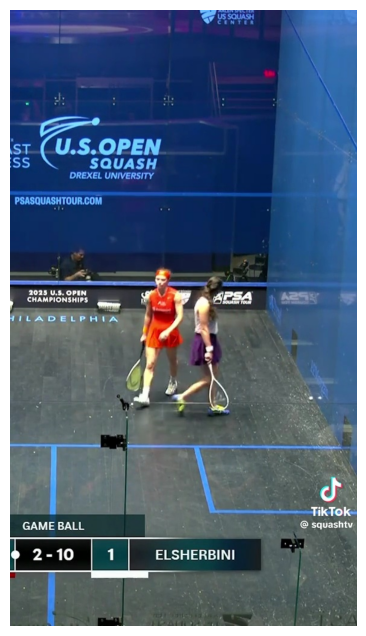

In [18]:
image = cv2.imread("../data/samples/frame_000216.jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

show_image(image_rgb)

## Preprocessing

In [19]:
gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

# GaussianBlur to reduce noise and help edge detection
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

edges = cv2.Canny(blurred, 50, 150)

In [20]:

# Morphological closing (dilate -> erode) to bridge gaps in edge segments
kernel = np.ones((5, 5), np.uint8)
dilated = cv2.dilate(edges, kernel, iterations=1)
eroded = cv2.erode(dilated, kernel, iterations=1)

## Contour Detection

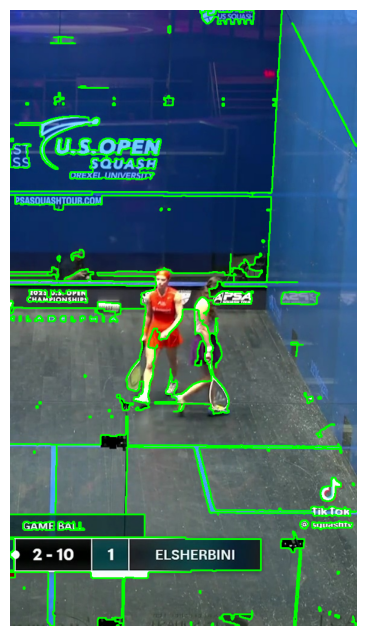

In [21]:
# Find contours in the eroded image
contours, _ = cv2.findContours(eroded, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
vis = image_rgb.copy()
vis = cv2.drawContours(vis, contours, -1, (0, 255, 0), 2)  # green, thickness 2
show_image(vis)

In [22]:
def filter_contours_by_area(contours, min_area):
    return [c for c in contours if cv2.contourArea(c) >= min_area]


def filter_contours_by_aspect_ratio(contours, min_ratio):
    filtered = []
    for c in contours:
        _, _, w, h = cv2.boundingRect(c)
        ratio = max(w, h) / max(min(w, h), 1)
        if ratio >= min_ratio:
            filtered.append(c)
    return filtered

Contours before filtering: 66
Contours after filtering:  19


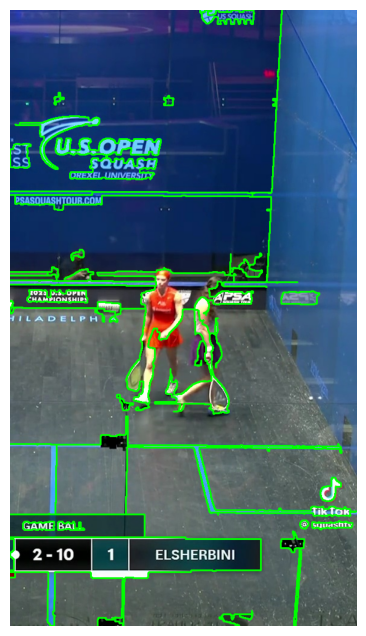

In [23]:
filtered = filter_contours_by_area(contours, min_area=100)
#filtered = filter_contours_by_aspect_ratio(filtered, min_ratio=1)

print(f"Contours before filtering: {len(contours)}")
print(f"Contours after filtering:  {len(filtered)}")

vis_filtered = image_rgb.copy()
cv2.drawContours(vis_filtered, filtered, -1, (0, 255, 0), 2)
show_image(vis_filtered)